<a href="https://colab.research.google.com/github/Vinicius-Araujppp/trabalho-mineracao-dados-jaqueline1bimestre/blob/main/01_classificacao_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Mineração de Dados - 1º Bimestre
**Tarefa:** Classificação
**Base de dados:** Breast Cancer Wisconsin (Diagnóstico Citológico)
## 1. Introdução
O objetivo deste notebook é aplicar algoritmos de classificação para prever se um tumor é benigno ou maligno, utilizando a base de dados citológica Breast Cancer Wisconsin. Visando melhorar a interpretabilidade, aplicaremos a técnica de Seleção de Atributos (RFE).

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Carregando os dados
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Exploração inicial
print("Dimensão dos dados originais:", X.shape)
print("Valores ausentes:", X.isna().sum().sum())
print("Distribuição das classes:")
print(pd.Series(y).value_counts().rename(index=dict(enumerate(data.target_names))))
print("Estatísticas das variáveis:")
display(X.describe().T[['mean', 'std', 'min', 'max']].head(10))

Dimensão dos dados originais: (569, 30)
Valores ausentes: 0
Distribuição das classes:
benign       357
malignant    212
Name: count, dtype: int64
Estatísticas das variáveis:


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Divisão 80/20 antes do pré-processamento, com estratificação
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ajuste do scaler apenas no treino para evitar vazamento de dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Treinando Regressão Logística com todos os 30 atributos
modelo_inicial = LogisticRegression(random_state=42)
modelo_inicial.fit(X_train, y_train)
y_pred_inicial = modelo_inicial.predict(X_test)

print("Acurácia Inicial:", accuracy_score(y_test, y_pred_inicial))
print("Relatório do modelo inicial:")
print(classification_report(y_test, y_pred_inicial, target_names=data.target_names))

Acurácia Inicial: 0.9824561403508771
Relatório do modelo inicial:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [4]:
from sklearn.feature_selection import RFE

# Aplicando Eliminação Recursiva de Atributos (RFE) reduzindo para 10 atributos
seletor_rfe = RFE(estimator=LogisticRegression(random_state=42), n_features_to_select=10)
seletor_rfe.fit(X_train, y_train)

# Filtrando os dados
X_train_selecionado = seletor_rfe.transform(X_train)
X_test_selecionado = seletor_rfe.transform(X_test)
atributos_selecionados = X.columns[seletor_rfe.support_]
print("Atributos selecionados pela RFE:")
print(list(atributos_selecionados))

# Re-treinamento com os atributos selecionados
modelo_otimizado = LogisticRegression(random_state=42)
modelo_otimizado.fit(X_train_selecionado, y_train)
y_pred_otimizado = modelo_otimizado.predict(X_test_selecionado)

print("Acurácia Pós-Seleção:", accuracy_score(y_test, y_pred_otimizado))
print("Relatório do modelo otimizado:")
print(classification_report(y_test, y_pred_otimizado, target_names=data.target_names))

Atributos selecionados pela RFE:
['mean area', 'radius error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concavity', 'worst concave points']
Acurácia Pós-Seleção: 0.9736842105263158
Relatório do modelo otimizado:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



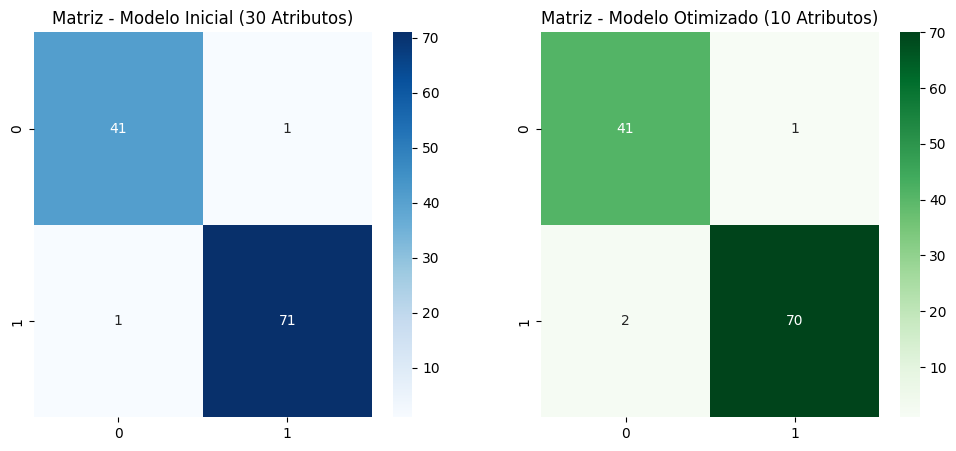

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gerando Matriz de Confusão para comparação
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_inicial), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz - Modelo Inicial (30 Atributos)')
sns.heatmap(confusion_matrix(y_test, y_pred_otimizado), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz - Modelo Otimizado (10 Atributos)')
plt.show()

## 7. Discussão dos resultados

O modelo inicial usa os 30 atributos e deve ser comparado ao modelo com 10 atributos selecionados pela RFE. A acurácia, a precisão, a revocação e o F1-score impressos nas células permitem verificar o custo da redução de dimensionalidade. Mesmo que o desempenho varie, o modelo otimizado é mais simples e facilita a interpretação dos atributos citológicos relevantes. As matrizes de confusão mostram também quais classes concentram os erros.

## 8. Conclusão

A RFE reduziu o modelo de 30 para 10 atributos. Neste experimento, a acurácia passou de aproximadamente 98,25% no modelo inicial para 97,37% após a seleção, uma pequena redução compensada pela maior simplicidade e interpretabilidade. Os relatórios de classificação e as matrizes de confusão permitem avaliar esse compromisso por classe.